Progetto: "AI Ghostwriter" - Adattamento e Tuning 

Scenario La demo tecnica basata su Shakespeare è stata un successo. Ora però il cliente, una casa editrice italiana ("Dante & Co."), vuole utilizzare la tecnologia per generare testo in lingua italiana nello stile della Divina Commedia. 
Inoltre, il cliente si è lamentato che a volte il testo è "troppo caotico" e altre volte "troppo ripetitivo". Devi intervenire sul codice per permettere loro di calibrare la creatività dell'AI. 

Obiettivi 
    1. Data Swapping: Sostituire il dataset di Shakespeare con quello di Dante Alighieri. 
    2. Hyperparameter Tuning: Modificare la "Temperatura" per trovare il bilanciamento perfetto tra grammatica corretta e creatività poetica. 
    3. Prompt Engineering: Adattare il seme di generazione (start_string) al nuovo contesto. 
    
Istruzioni Operative 

1. Analisi del Prototipo (Shakespeare) 
Esegui il codice base fornito (quello su Shakespeare) così com'è. Assicurati che funzioni e genera una frase di test. 
    * Analisi: Osserva l'output della funzione elabora_dizionari . Quanti caratteri unici usava Shakespeare? 
    * Annota questo numero, ti servirà per il confronto. 
    
2. Cambio del Dataset (Dante Alighieri) 
Dobbiamo cambiare la fonte dei dati. Il metodo get_file di Keras a volte dà problemi con link esterni, quindi useremo la libreria standard requests .
    * Task: modifica la funzione di download (o creane una nuova scarica_testo_dante) utilizzando questo link specifiche che abbiamo verificato essere funzionante:
    https://dmf.unicatt.it/~della/pythoncourse18/commedia.txt 
    * Encoding: L'italiano ha accenti (à, è, ì, ò, ù). Se non specifichi la codifica, vedrai simboli strani. Assicurati di impostare response.encoding = 'utf-8' . 
    
    ** Suggerimento Codice:** 
    import requests 
    import urllib3 
    
    # Disabilitiamo i messaggi di avviso "InsecureRequestWarning" per avere un output pulito 
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning) 
    
    def scarica_testo_dante():     
        """     Scarica la Divina Commedia ignorando gli errori di certificato SSL.     """     
        url = "https://dmf.unicatt.it/~della/pythoncourse18/commedia.txt"     
        print(f"Scaricamento testo da: {url}...")     
        try:         
            # AGGIUNTA FONDAMENTALE: verify=False         
            # Dice a Python: "Fidati del server anche se non riconosci il certificato        "         
            response = requests.get(url, verify=False)         
            response.raise_for_status()         
            response.encoding = 'utf-8'          
            text = response.text         
            print(f"Download completato. Lunghezza testo: {len(text)} caratteri")         
            print(f"Esempio (primi 100 caratteri):\n{text[:100]}")         
            return text     
        except Exception as e:         
            print(f"Errore ancora presente: {e}") 
            # Se fallisce anche così, usiamo un link alternativo di GitHub (spesso più compatibile)
            print("Tentativo con link di riserva (GitHub)...")         
            try:             
                url_backup = "https://raw.githubusercontent.com/wpm/t-snetext-vis/master/data/divina_commedia.txt"             
                r2 = requests.get(url_backup, verify=False)             
                r2.encoding = 'utf-8'             
                return r2.text         
            except:             
                return None 
        # Eseguiamo il download 
        text = scarica_testo_dante() 

3. Adattamento dei Parametri di Training 
Dante scrive in terzine ed è molto strutturato, diversamente dai monologhi inglesi. 
    * Modifica crea_dataset_addestramento : Le terzine di Dante sono più brevi. Prova a modificare seq_length (lunghezza sequenza). Invece di 100 caratteri, prova a scendere a 80 o 60. 
    * Riflessione: Come influisce questo cambiamento sulla velocità di ogni epoca? 
    
4. Training (Addestramento) 
    * Rilancia l'addestramento sul nuovo testo. 
    * Consiglio: Poiché stiamo cambiando lingua e struttura, monitora la loss . Se non scende abbastanza, potresti dover aumentare il numero di epochs (prova almeno 10-20 epoche per risultati leggibili). 

5. Generazione e Tuning della Temperatura (Il cuore dell'esercizio) 
Il cliente vuole controllare lo stile. Modifica la parte finale ( main e genera_testo ): 
    1. Cambia il Prompt: Non usare più "ROMEO: " . Usa qualcosa di dantesco, es: "Nel mezzo " , "Selva " o "Virgilio ". 
    2. Esperimento Temperatura: Genera testo con tre configurazioni diverse e osserva i risultati: 
        * Temp = 0.2 (Freddo/Conservativo): Il modello entra in loop ripetendo sempre la stessa parola o frase? 
        * Temp = 1.0 (Standard): La sintassi e la grammatica reggono?
        * Temp = 2.0 (Caldo/Folle): Ci sono parole inventate? Sembra una lingua aliena?

Al termine del notebook, aggiungi una cella di testo con le tue conclusioni: 
    1. Quale temperatura ha generato la "terzina" più credibile? 
    2. Incolla qui sotto il miglior testo generato dalla tua AI.

Nel modello della lezione, quello riferito a Shekespeare, venivano utilizzati 65 vocaboli (calcolati e stampanti più aventi nel codcice). In questo modello 69 caratteri unici. Sostanzialmente non c'è molta differenza. 
Sostanzialmente non c'è molta differenza, i modelli devono scieglire il carattere successivo tra un numero simile di possibilità. In entrambi i casi il modello deve sceglire il carattere sucessivo

Il cambio di lunghezza della sequenza da 100 a 80 a 60 ha dimostrato che influenza la velocità. 
Questo perchè ogni sequenza è più corta, ogni batch richiede meno moemoria, la GRU deve propagare il gradiente con meno passi.
Il numero complessivo di caratteri processati in un'epoca resta quasi identico. Di conseguenza l'epoca può essere più gestibile e stabile, ma non necessariamente molto più veloce.

In [1]:
# VERIFICA AMBIENTE

import os
os.environ["KERAS_BACKEND"] = "torch"

import sys
import site
import requests
import urllib3
import numpy as np
import keras
import torch
import matplotlib.pyplot as plt

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
keras.utils.set_random_seed(42)

print("Python:", sys.executable)
print("Versione Python:", sys.version)
print("Keras:", keras.__version__)
print("Backend Keras:", keras.backend.backend())
print("PyTorch:", torch.__version__)
print("CUDA disponibile:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Training su CPU")


Python: c:\Program Files\Python312\python.exe
Versione Python: 3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]
Keras: 3.15.1
Backend Keras: torch
PyTorch: 2.13.0+cpu
CUDA disponibile: False
Training su CPU


In [2]:
def scarica_testo_dante():
    url = "https://dmf.unicatt.it/~della/pythoncourse18/commedia.txt"
    print(f"Scarico testo da: {url}...")

    try:
        response = requests.get(url, verify=False, timeout=30)
        response.raise_for_status()
        response.encoding = "utf-8"

        text = response.text

        print(
            f"Download completato. "
            f"Lunghezza testo: {len(text)} caratteri"
        )
        return text

    except Exception as e:
        print(f"Errore sul primo indirizzo: {e}")
        print("Tentativo con link di riserva...")

        try:
            url_backup = (
                "https://raw.githubusercontent.com/"
                "wpm/t-snetext-vis/master/data/"
                "divina_commedia.txt"
            )

            response = requests.get(
                url_backup,
                verify=False,
                timeout=30
            )
            response.raise_for_status()
            response.encoding = "utf-8"

            return response.text

        except Exception as backup_error:
            raise RuntimeError(
                "Impossibile scaricare il testo"
            ) from backup_error

In [3]:
text = scarica_testo_dante()
if not text:
    raise ValueError("Il testo scaricato è vuoto o None")
#print(text[:500])

Scarico testo da: https://dmf.unicatt.it/~della/pythoncourse18/commedia.txt...
Download completato. Lunghezza testo: 551846 caratteri


In [4]:
# VOCABOLARIO E CODIFICA

vocab = sorted(set(text))
vocab_size = len(vocab)

char2idx = {carattere: indice for indice, carattere in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[carattere] for carattere in text],dtype=np.int64)

print(f"Caratteri unici: {vocab_size}")
print(f"Lunghezza corpus: {len(text_as_int):,}")
print("Primi 10 valori:", text_as_int[:10])



Caratteri unici: 69
Lunghezza corpus: 551,846
Primi 10 valori: [23 14  2 17 22 33 22 25 14  2]


In [5]:
SEQ_LENGTH = 80
BATCH_SIZE = 32
TRAIN_FRACTION = 0.90

split_index = int(len(text_as_int) * TRAIN_FRACTION)

train_ids = text_as_int[:split_index]
val_ids = text_as_int[split_index:]


def crea_sequenze(encoded_text, seq_length):
    numero_sequenze = (len(encoded_text) - 1) // seq_length

    if numero_sequenze < 1:
        raise ValueError("Testo insufficiente per creare le sequenze")

    lunghezza_utile = numero_sequenze * seq_length + 1
    encoded_text = encoded_text[:lunghezza_utile]

    x = np.stack([encoded_text[i * seq_length: i * seq_length + seq_length] for i in range(numero_sequenze)])
    y = np.stack([encoded_text[i * seq_length + 1: i * seq_length + seq_length + 1] for i in range(numero_sequenze)])

    return x.astype(np.int64), y.astype(np.int64)


x_train, y_train = crea_sequenze(train_ids, SEQ_LENGTH)
x_val, y_val = crea_sequenze(val_ids, SEQ_LENGTH)

print("Training:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Batch training per epoca:", len(x_train) // BATCH_SIZE)


Training: (6208, 80) (6208, 80)
Validation: (689, 80) (689, 80)
Batch training per epoca: 194


MODELLO

In [6]:
EMBEDDING_DIM = 64 #dimensione del vettore che rappresenta il carattere corrente
RNN_UNITS = 256 #dimensione della memoria con cui la GRU rappresenta il contesto
#La GRU legge il carattere rappresentato dall'EMBEDDING_DIM ed aggiorna la propria memoria 
#con una dimensione di runn_units
DROPOUT_RATE = 0.15 #percentuale di informazione che il modellO spegne casualmente con dropout
LEARNING_RATE = 5e-4


def build_model(
    vocab_size,
    embedding_dim=EMBEDDING_DIM,
    rnn_units=RNN_UNITS,
    dropout_rate=DROPOUT_RATE
):
    inputs = keras.layers.Input(shape=(None,),dtype="int64")
    #Embedding: trasforma ogni indice (ogni numero associato ai vari caratteri) in un vettore di numeri 
    # (che vengono utilizzati per rappresentare ogni carattere prima che il dato entri nella GRU)
    # la dimensione del vettore è embedding_dim
    # LAYER EMBEDDING: rappresenta l'elemento corrente
    x = keras.layers.Embedding(input_dim=vocab_size,output_dim=embedding_dim,name="embedding")(inputs)
    # LAYER SPATIALDROPOUT1D simile al dropout ma spegne intere dimensioni dell'embedding. 
    # Cioè spegne, casualmente, per esempio le dimensioni 2 per tutti gli 80 caratteri della stessa sequenza.
    x = keras.layers.SpatialDropout1D(dropout_rate, name="embedding_dropout")(x)
    # LAYER GRU: rappresenta la memoria, per sintetizzare ciò che è stato letto fino al momento
    x = keras.layers.GRU(rnn_units,return_sequences=True,stateful=False,recurrent_initializer="orthogonal",name="gru")(x)
    # LAYER DOPOUT: layer che spegne alcuni neuroni
    x = keras.layers.Dropout(dropout_rate,name="output_dropout")(x)
    # LAYER DENSE: trasforma ciò che ha capito la rete nella previsoine finale
    outputs = keras.layers.Dense(vocab_size,name="logits")(x)

    return keras.Model(inputs, outputs, name="dante_char_gru")


model = build_model(vocab_size)

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0)
model.compile(optimizer=optimizer, loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")])

model.summary()


Model: "dante_char_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 64)       │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dropout               │ (None, None, 64)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 256)      │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dropout (Dropout)        │ (None, None, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, None, 69)       │        17,733 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,445 (1.03 MB)

 Trainable params: 269,445 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

CALCOLO DELLA LOSS
Tutte le decisoine le prendo sulla val_loss
* ReduceLROnPlateay: riduce lr quando la qualità sui daiti non visti smette di migliorare
* EarlyStopping: evita epoche inutili e ripristina i pesi migliori.
* TerminalOnNan: interrompe un training instabile

In [7]:
MAX_EPOCHS = 60

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_delta=0.002,
        cooldown=1,
        min_lr=1e-5,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=8,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_dante_model.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        "training_dante.csv"
    ),
    keras.callbacks.TerminateOnNaN()
]

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=MAX_EPOCHS,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

model.save("dante_ottimizzato.keras")


Epoch 1/60
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.2032 - loss: 3.0529
Epoch 1: val_loss improved from None to 2.46883, saving model to best_dante_model.keras

Epoch 1: finished saving model to best_dante_model.keras
194/194 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.2032 - loss: 3.0529 - val_accuracy: 0.2871 - val_loss: 2.4688 - learning_rate: 5.0000e-04
Epoch 2/60
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3144 - loss: 2.3396
Epoch 2: val_loss improved from 2.46883 to 2.18530, saving model to best_dante_model.keras

Epoch 2: finished saving model to best_dante_model.keras
194/194 ━━━━━━━━━━━━━━━━━━━━ 23s 120ms/step - accuracy: 0.3144 - loss: 2.3396 - val_accuracy: 0.3472 - val_loss: 2.1853 - learning_rate: 5.0000e-04
Epoch 3/60
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3413 - loss: 2.1584
Epoch 3: val_loss improved from 2.18530 to 2.06000, saving model to best_dante_model.keras

Epoch 3: finished saving model to best_dante_model.ke

Importante verificare la metriche su training e su validation
* entrambe scendono: modello sta imparando
* training scende, validation sale: modello sta overfittando
* training e validation alte: modello fermo, underfittando
* andamento irregolare: lr eccessivo, diminuire

La migliore epoca per il modello è la 55. Il modello ora in memoria è il modello migliore.
Il modello non mostra overfittin, ha raggiunto l'epoca migliore, si è fermato correttamente
Accuracy del 54%, vuol dire che il singolo carattere successivo sarà correto al 54%

Epoch 55: finished saving model to best_dante_model.keras
194/194 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - accuracy: 0.5414 - loss: 1.4444 - val_accuracy: 0.5386 - val_loss: 1.4643 - learning_rate: 6.2500e-05
Epoch 56/60
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5421 - loss: 1.4438
Epoch 56: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

In [8]:
train_loss = np.array(history.history["loss"])
val_loss = np.array(history.history["val_loss"])

best_epoch = int(np.argmin(val_loss)) + 1
best_val_loss = float(np.min(val_loss))
best_train_loss = float(train_loss[best_epoch - 1])

train_perplexity = float(np.exp(best_train_loss))
val_perplexity = float(np.exp(best_val_loss))

print(f"Epoca migliore: {best_epoch}")
print(f"Training loss: {best_train_loss:.4f}")
print(f"Validation loss: {best_val_loss:.4f}")
print(f"Training perplexity: {train_perplexity:.3f}")
print(f"Validation perplexity: {val_perplexity:.3f}")
print(
    "Learning rate finale:",
    float(keras.ops.convert_to_numpy(model.optimizer.learning_rate))
)


Epoca migliore: 60
Training loss: 1.4415
Validation loss: 1.4639
Training perplexity: 4.227
Validation perplexity: 4.323
Learning rate finale: 1.5625000742147677e-05


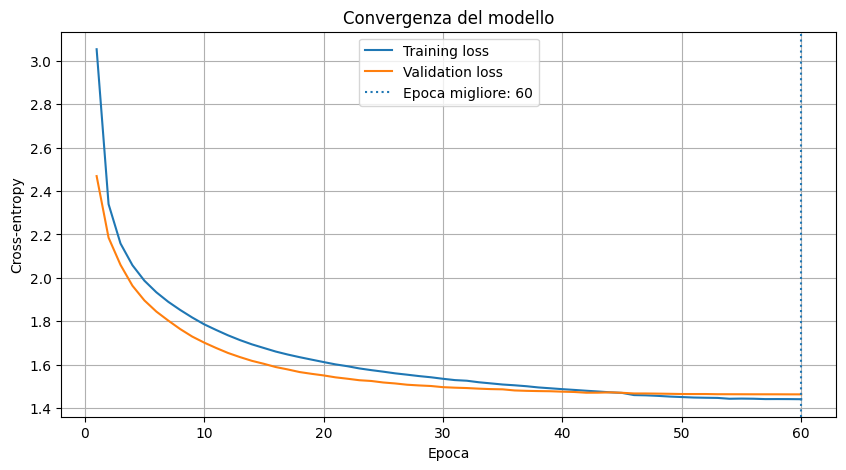

In [9]:
epoche = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epoche, train_loss, label="Training loss")
plt.plot(epoche, val_loss, label="Validation loss")
plt.axvline(
    best_epoch,
    linestyle=":",
    label=f"Epoca migliore: {best_epoch}"
)
plt.xlabel("Epoca")
plt.ylabel("Cross-entropy")
plt.title("Convergenza del modello")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# GENERAZIONE COERENTE CON IL BACKEND PYTORCH

def generate_text(
    model,
    start_string,
    temperature=0.7,
    num_generate=400,
    context_length=SEQ_LENGTH
):
    if temperature <= 0:
        raise ValueError("La temperatura deve essere maggiore di zero")

    caratteri_sconosciuti = [
        carattere
        for carattere in start_string
        if carattere not in char2idx
    ]

    if caratteri_sconosciuti:
        raise ValueError(
            "Caratteri non presenti nel vocabolario: "
            f"{sorted(set(caratteri_sconosciuti))}"
        )

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    input_ids = torch.tensor(
        [[char2idx[c] for c in start_string]],
        dtype=torch.long,
        device=device
    )

    generated_chars = []

    with torch.inference_mode():
        for _ in range(num_generate):
            logits = model(
                input_ids,
                training=False
            )

            next_logits = logits[:, -1, :] / temperature
            probabilities = torch.softmax(
                next_logits,
                dim=-1
            )

            predicted_id = torch.multinomial(
                probabilities,
                num_samples=1
            )

            input_ids = torch.cat(
                [input_ids, predicted_id],
                dim=1
            )

            if input_ids.shape[1] > context_length:
                input_ids = input_ids[:, -context_length:]

            generated_chars.append(
                idx2char[int(predicted_id.item())]
            )

    return start_string + "".join(generated_chars)


for temperatura in (0.2, 1.0, 2.0):
    print(f"\nTEMPERATURA {temperatura}")
    print(
        generate_text(
            model,
            start_string="Nel mezzo",
            temperature=temperatura,
            num_generate=400
        )
    )
    print("=" * 70)



TEMPERATURA 0.2
Nel mezzo de la sua vita
lo suo parlar di quel che si convene
che si vente a la sua vista si porte.
  Lo mio disio di sù la sua parte risposta,
come fu da la sua parte a la fiamma
che si vede in te stesso le cose terra,
  così vid'io l'altro si ricoperchia
che si verso a la sua vita e stranne,
che la mia vita sentia si stessa
per la vita sanza corpo si ricole.
  Questi che 'l mondo si ricorda,
c

TEMPERATURA 1.0
Nel mezzo;
ma loco dietro a Caliaso vede.
  Dolce a formo al tempo e dove lor paco,
  e però seme".
  Ed elli a paè, sì che li antica scorde;
  e però ch'io muccia 'l monte contenta
che dal deco su per le terra fanto.
  Noi esserti 'l poi, trapia se non li alti.
  Ben poco gridar sua sovra 'l pieda liena
del viso celiri in diverse creco
fiamma già li conficer li son pono.
  Tician di sé stanno, 

TEMPERATURA 2.0
Nel mezzo,
pard'or revre i issigridem miei;
  "Egrav novvediio H;cesso
onundi!,oChì vele e qui ertegno:
e nublieti; quanco: CaDDevalture,
dé'.
no", Cat

Interpretazione temperatura:
    * Temperatura 0.2: testo più conservativo, risultato migliore. Il modello sceglie quasi sempre le lettere più probabili
    * Temporatura 1.0: testo più creativo ma più instabile. Il modello produce molte parole inventate
    * Temperatura 2.0: testo creativo molto instabile. Il modello produce caratteri casuali, puntuggiatura all'interno di parole, illegibile
Sembra che il modello non ha imparato il significato delle parole. E' coerente con un modello character-level. Il modello genera una letttera alla volta, non ragiona direttamente per parole o concetti

Il modello è stato addestrato su un'unica opera, è un dataset picoclo per generazione linguistica pura.

